**<h1>🚀 Phase 1: EDA Lengkap – Dataset Perkebunan Coklat 2024-2026</h1>**

**<h2>Langkah 1: Setup Environment</h2>**

In [1]:
!pip install -q pandas numpy matplotlib seaborn plotly plotly.express kaleido

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from google.colab import files
from datetime import datetime

**<h2>Langkah 2: Upload File CSV</h2>**

In [2]:
# Upload file CSV lo
print("Silakan upload file dataset_perkebunan_coklat_2024_2026.csv")
uploaded = files.upload()

# Ambil nama file yang di-upload
filename = list(uploaded.keys())[0]
print(f"✅ File berhasil di-upload: {filename}")

Silakan upload file dataset_perkebunan_coklat_2024_2026.csv


Saving dataset_perkebunan_coklat_2024_2026.csv to dataset_perkebunan_coklat_2024_2026.csv
✅ File berhasil di-upload: dataset_perkebunan_coklat_2024_2026.csv


**<h2>Langkah 3: Load &amp; Inspect Data</h2>**

In [3]:
# Load dataset
df = pd.read_csv(filename)

In [4]:
# Tampilkan 5 baris pertama
print("=== 5 Baris Pertama ===")
display(df.head())

=== 5 Baris Pertama ===


,Tanggal,Wilayah,Jenis_Perkebunan,Jenis_Proses,Produksi_kg,Harga_per_kg_IDR,Kualitas
0,2025-12-10,Sulawesi,Perkebunan Swasta,Roasting,888.09,41341.02,Grade C
1,2024-05-15,Bali,Perkebunan Swasta,Roasting,1474.44,31802.06,Grade C
2,2025-11-17,Sumatera,Perkebunan Swasta,Roasting,586.48,39023.55,Grade C
3,2025-06-05,Sulawesi,Perkebunan Negara,Fermentasi,1455.99,54599.78,Grade C
4,2026-01-24,NTT,Perkebunan Negara,Roasting,421.91,43971.40,Grade A


In [5]:
# Info dataset
print("\n=== Info Dataset ===")
print(df.info())


=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Tanggal           1000 non-null   object 
 1   Wilayah           1000 non-null   object 
 2   Jenis_Perkebunan  1000 non-null   object 
 3   Jenis_Proses      1000 non-null   object 
 4   Produksi_kg       1000 non-null   float64
 5   Harga_per_kg_IDR  1000 non-null   float64
 6   Kualitas          1000 non-null   object 
dtypes: float64(2), object(5)
memory usage: 54.8+ KB
None


In [6]:
# Statistik deskriptif
print("\n=== Statistik Deskriptif ===")
display(df.describe())


=== Statistik Deskriptif ===


,Produksi_kg,Harga_per_kg_IDR
count,1000.000000,1000.000000
mean,1100.713340,43043.482590
std,522.596387,9983.764197
min,204.830000,25058.200000
25%,630.822500,34739.615000
50%,1113.780000,43030.465000
75%,1552.467500,51806.657500
max,1998.550000,59998.150000


In [7]:
# Cek missing values
print("\n=== Missing Values ===")
print(df.isnull().sum())


=== Missing Values ===
Tanggal             0
Wilayah             0
Jenis_Perkebunan    0
Jenis_Proses        0
Produksi_kg         0
Harga_per_kg_IDR    0
Kualitas            0
dtype: int64


**<h2>Langkah 4: Data Cleaning + Feature Engineering</h2>**

In [8]:
# Ubah Tanggal jadi datetime
df['Tanggal'] = pd.to_datetime(df['Tanggal'])

# Buat kolom Profit (target utama kita)
df['Profit'] = df['Produksi_kg'] * df['Harga_per_kg_IDR']

# Ekstrak waktu
df['Year'] = df['Tanggal'].dt.year
df['Month'] = df['Tanggal'].dt.month
df['Month_Name'] = df['Tanggal'].dt.strftime('%B')
df['Quarter'] = df['Tanggal'].dt.quarter

print("✅ Kolom Profit + waktu berhasil ditambahkan!")
display(df.head())

✅ Kolom Profit + waktu berhasil ditambahkan!


,Tanggal,Wilayah,Jenis_Perkebunan,Jenis_Proses,Produksi_kg,Harga_per_kg_IDR,Kualitas,Profit,Year,Month,Month_Name,Quarter
0,2025-12-10,Sulawesi,Perkebunan Swasta,Roasting,888.09,41341.02,Grade C,3.671455e+07,2025,12,December,4
1,2024-05-15,Bali,Perkebunan Swasta,Roasting,1474.44,31802.06,Grade C,4.689023e+07,2024,5,May,2
2,2025-11-17,Sumatera,Perkebunan Swasta,Roasting,586.48,39023.55,Grade C,2.288653e+07,2025,11,November,4
3,2025-06-05,Sulawesi,Perkebunan Negara,Fermentasi,1455.99,54599.78,Grade C,7.949673e+07,2025,6,June,2
4,2026-01-24,NTT,Perkebunan Negara,Roasting,421.91,43971.40,Grade A,1.855197e+07,2026,1,January,1


**<h2>Langkah 5: Exploratory Data Analysis (EDA Lengkap)</h2>**

<h3>5.1 Distribusi Produksi, Harga, dan Profit</h3>

In [9]:
fig = make_subplots(rows=1, cols=3, subplot_titles=('Produksi (kg)', 'Harga/kg (IDR)', 'Profit (IDR)'))

fig.add_trace(go.Histogram(x=df['Produksi_kg'], name='Produksi'), row=1, col=1)
fig.add_trace(go.Histogram(x=df['Harga_per_kg_IDR'], name='Harga'), row=1, col=2)
fig.add_trace(go.Histogram(x=df['Profit'], name='Profit'), row=1, col=3)

fig.update_layout(height=400, title_text="Distribusi Produksi, Harga, dan Profit")
fig.show()

/usr/local/lib/python3.12/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




<h3>5.2 Rata-rata per Wilayah, Jenis Perkebunan, Proses, dan Kualitas</h3>

In [10]:
metrics = ['Produksi_kg', 'Harga_per_kg_IDR', 'Profit']

for col in ['Wilayah', 'Jenis_Perkebunan', 'Jenis_Proses', 'Kualitas']:
    agg = df.groupby(col)[metrics].mean().round(2)
    print(f"\n=== Rata-rata per {col} ===")
    display(agg)

    # Visualisasi Profit
    fig = px.bar(agg.reset_index(), x=col, y='Profit',
                 title=f'Rata-rata Profit per {col}',
                 color='Profit', color_continuous_scale='Viridis')
    fig.show()


=== Rata-rata per Wilayah ===


,Produksi_kg,Harga_per_kg_IDR,Profit
Wilayah,,,
Bali,1040.64,43049.59,44603521.62
Jawa Barat,1072.40,44064.61,47435738.94
Jawa Timur,1197.17,42586.48,51001700.31
NTT,1068.28,42826.12,44948051.44
Sulawesi,1128.36,42322.90,48215265.61
Sumatera,1096.45,43403.66,47159302.93



=== Rata-rata per Jenis_Perkebunan ===


,Produksi_kg,Harga_per_kg_IDR,Profit
Jenis_Perkebunan,,,
Perkebunan Negara,1155.06,42825.08,49122683.35
Perkebunan Rakyat,1044.78,43398.95,45201170.04
Perkebunan Swasta,1105.27,42891.36,47488822.61



=== Rata-rata per Jenis_Proses ===


,Produksi_kg,Harga_per_kg_IDR,Profit
Jenis_Proses,,,
Fermentasi,1090.05,44067.37,48232179.55
Pengeringan,1102.98,41656.59,45545386.71
Penggilingan,1146.73,42940.73,48928119.65
Roasting,1057.17,43547.05,46054009.97



=== Rata-rata per Kualitas ===


,Produksi_kg,Harga_per_kg_IDR,Profit
Kualitas,,,
Grade A,1100.53,42832.96,47481716.54
Grade B,1087.79,43557.78,47309975.60
Grade C,1113.36,42738.09,46940925.51


<h3>5.3 Time Series Trend (Produksi &amp; Profit per Bulan)</h3>

In [11]:
monthly = df.groupby(['Year', 'Month_Name']).agg({
    'Produksi_kg': 'mean',
    'Profit': 'mean',
    'Harga_per_kg_IDR': 'mean'
}).reset_index()

fig = px.line(monthly, x='Month_Name', y=['Produksi_kg', 'Profit'],
              color='Year', markers=True,
              title='Tren Rata-rata Produksi & Profit per Bulan (2024-2026)')
fig.show()

<h3>5.4 Heatmap Korelasi</h3>

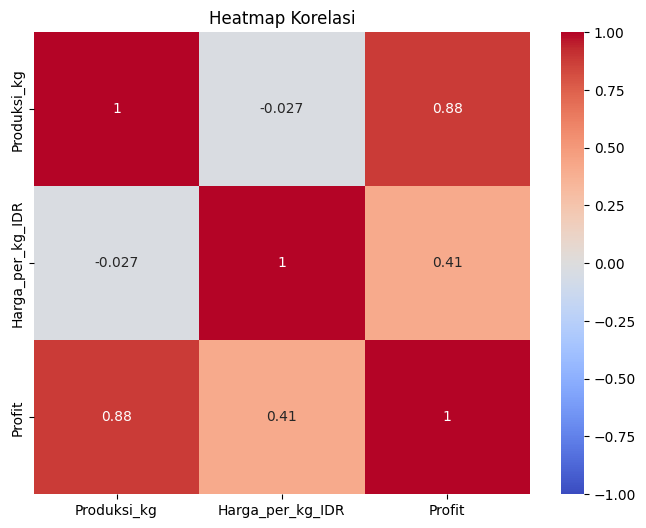

In [12]:
# Korelasi antar variabel numerik
numeric_cols = ['Produksi_kg', 'Harga_per_kg_IDR', 'Profit']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap Korelasi')
plt.show()

<h3>5.5 Boxplot: Profit berdasarkan Kombinasi Kualitas &amp; Proses</h3>

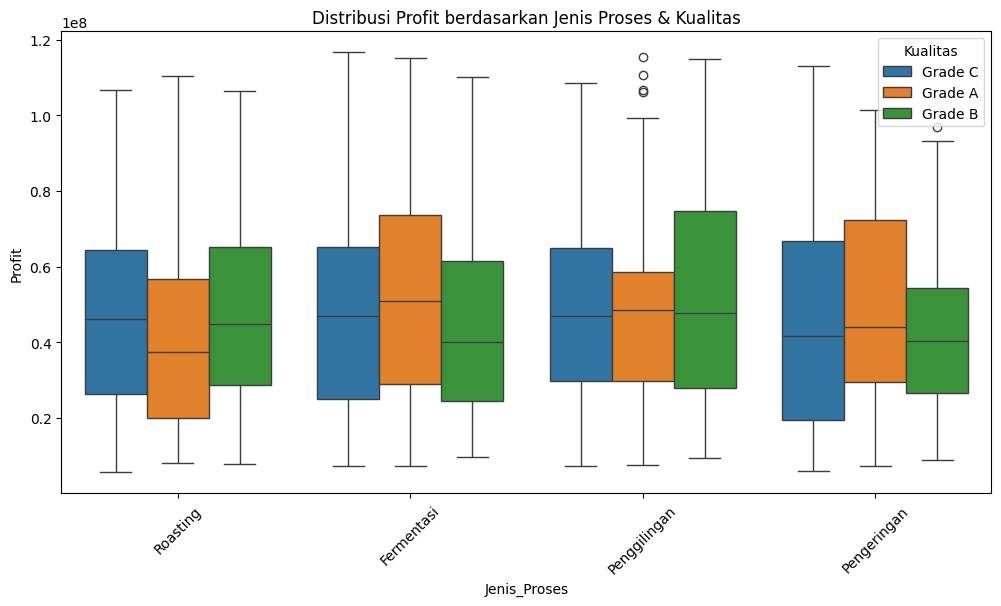

In [13]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Jenis_Proses', y='Profit', hue='Kualitas')
plt.title('Distribusi Profit berdasarkan Jenis Proses & Kualitas')
plt.xticks(rotation=45)
plt.show()

<h3>5.6 Top 10 Kombinasi Terbaik (Profit Tertinggi)</h3>

In [14]:
df['Kombinasi'] = df['Wilayah'] + " | " + df['Jenis_Perkebunan'] + " | " + df['Jenis_Proses']

top10 = df.groupby('Kombinasi')['Profit'].agg(['mean', 'count']).round(2).sort_values('mean', ascending=False).head(10)
print("🔥 TOP 10 Kombinasi Paling Menguntungkan:")
display(top10)

🔥 TOP 10 Kombinasi Paling Menguntungkan:


,mean,count
Kombinasi,,
Jawa Timur | Perkebunan Swasta | Penggilingan,64981582.16,15
Jawa Barat | Perkebunan Rakyat | Fermentasi,61870530.08,13
Jawa Timur | Perkebunan Negara | Pengeringan,60963999.03,14
Sulawesi | Perkebunan Negara | Roasting,60091276.86,18
NTT | Perkebunan Swasta | Pengeringan,56565329.42,18
Jawa Timur | Perkebunan Swasta | Fermentasi,55937825.76,17
Sumatera | Perkebunan Negara | Pengeringan,55840826.04,10
Jawa Timur | Perkebunan Negara | Penggilingan,55466571.57,16
Sumatera | Perkebunan Negara | Roasting,55440421.49,16


**<h1>🚀 Phase 2: Predictive Model – Baseline Regressor (Oracle untuk RL)</h1>**

**<h2>Langkah 1: Setup Library</h2>**

In [15]:
!pip install -q xgboost scikit-learn joblib plotly kaleido

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import joblib
from google.colab import files

**<h2>Langkah 2: Load Dataset Clean dari Phase 1</h2>**

In [16]:
print("Upload file clean dari Phase 1 (dataset_perkebunan_coklat_clean.csv)")
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
df['Tanggal'] = pd.to_datetime(df['Tanggal'])

print("✅ Dataset clean berhasil di-load!")
display(df.head())
print(df.shape)

Upload file clean dari Phase 1 (dataset_perkebunan_coklat_clean.csv)


Saving dataset_perkebunan_coklat_clean.csv to dataset_perkebunan_coklat_clean.csv
✅ Dataset clean berhasil di-load!


,Tanggal,Wilayah,Jenis_Perkebunan,Jenis_Proses,Produksi_kg,Harga_per_kg_IDR,Kualitas,Profit,Year,Month,Month_Name,Quarter,Kombinasi
0,2025-12-10,Sulawesi,Perkebunan Swasta,Roasting,888.09,41341.02,Grade C,3.671455e+07,2025,12,December,4,Sulawesi | Perkebunan Swasta | Roasting
1,2024-05-15,Bali,Perkebunan Swasta,Roasting,1474.44,31802.06,Grade C,4.689023e+07,2024,5,May,2,Bali | Perkebunan Swasta | Roasting
2,2025-11-17,Sumatera,Perkebunan Swasta,Roasting,586.48,39023.55,Grade C,2.288653e+07,2025,11,November,4,Sumatera | Perkebunan Swasta | Roasting
3,2025-06-05,Sulawesi,Perkebunan Negara,Fermentasi,1455.99,54599.78,Grade C,7.949673e+07,2025,6,June,2,Sulawesi | Perkebunan Negara | Fermentasi
4,2026-01-24,NTT,Perkebunan Negara,Roasting,421.91,43971.40,Grade A,1.855197e+07,2026,1,January,1,NTT | Perkebunan Negara | Roasting


(1000, 13)


**<h2>Langkah 3: Feature Engineering untuk Modeling</h2>**

In [17]:
# Encode categorical features
categorical_cols = ['Wilayah', 'Jenis_Perkebunan', 'Jenis_Proses', 'Kualitas']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Time features (cyclical + basic)
df_encoded['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df_encoded['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
df_encoded['Year'] = df['Year']

# Features yang akan dipakai model
feature_cols = [col for col in df_encoded.columns if col not in
                ['Tanggal', 'Month_Name', 'Produksi_kg', 'Harga_per_kg_IDR', 'Profit']]

print("✅ Feature engineering selesai!")
print("Jumlah fitur:", len(feature_cols))
print("Contoh fitur:", feature_cols[:10])

✅ Feature engineering selesai!
Jumlah fitur: 18
Contoh fitur: ['Year', 'Month', 'Quarter', 'Kombinasi', 'Wilayah_Jawa Barat', 'Wilayah_Jawa Timur', 'Wilayah_NTT', 'Wilayah_Sulawesi', 'Wilayah_Sumatera', 'Jenis_Perkebunan_Perkebunan Rakyat']


**<h2>Langkah 4: Train-Test Split (Time-based)</h2>**

In [18]:
# Sort berdasarkan waktu (penting untuk time series)
df_encoded = df_encoded.sort_values('Tanggal')

# Split: train = 2024 + 2025, test = 2026
train_df = df_encoded[df_encoded['Year'] <= 2025]
test_df  = df_encoded[df_encoded['Year'] == 2026]

X_train = train_df[feature_cols]
y_train_prod = train_df['Produksi_kg']
y_train_price = train_df['Harga_per_kg_IDR']
y_train_profit = train_df['Profit']

X_test = test_df[feature_cols]
y_test_prod = test_df['Produksi_kg']
y_test_price = test_df['Harga_per_kg_IDR']
y_test_profit = test_df['Profit']

print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")
print(f"Test period: {test_df['Tanggal'].min()} sampai {test_df['Tanggal'].max()}")

Train shape: (923, 18) | Test shape: (77, 18)
Test period: 2026-01-02 00:00:00 sampai 2026-02-27 00:00:00


**<h2>Langkah 5: Training 3 Model XGBoost</h2>**

In [19]:
# Fix: Pastikan fitur hanya berisi data numerik (hapus kolom 'Kombinasi' jika ada)
X_train_fixed = X_train.drop(columns=['Kombinasi'], errors='ignore')
X_test_fixed = X_test.drop(columns=['Kombinasi'], errors='ignore')

# Model 1: Prediksi Produksi_kg
model_prod = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
model_prod.fit(X_train_fixed, y_train_prod)

# Model 2: Prediksi Harga_per_kg_IDR
model_price = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
model_price.fit(X_train_fixed, y_train_price)

# Model 3 (bonus): Prediksi Profit langsung
model_profit = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
model_profit.fit(X_train_fixed, y_train_profit)

print("✅ Ketiga model sudah di-training tanpa kolom Kombinasi!")

✅ Ketiga model sudah di-training tanpa kolom Kombinasi!


**<h2>Langkah 6: Evaluasi Model</h2>**

In [20]:
def evaluate_model(model, X_test, y_true, name):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n=== {name} ===")
    print(f"MAE   : {mae:,.2f}")
    print(f"RMSE  : {rmse:,.2f}")
    print(f"R²    : {r2:.4f}")
    return y_pred

# Evaluasi menggunakan X_test_fixed yang sudah bersih dari kolom non-numerik
pred_prod = evaluate_model(model_prod, X_test_fixed, y_test_prod, "Produksi_kg")
pred_price = evaluate_model(model_price, X_test_fixed, y_test_price, "Harga_per_kg_IDR")
pred_profit = evaluate_model(model_profit, X_test_fixed, y_test_profit, "Profit")


=== Produksi_kg ===
MAE   : 543.98
RMSE  : 645.57
R²    : -0.5282

=== Harga_per_kg_IDR ===
MAE   : 11,062.83
RMSE  : 13,062.72
R²    : -0.9765

=== Profit ===
MAE   : 25,049,560.54
RMSE  : 30,104,636.77
R²    : -0.4398


**<h2>Langkah 7: Visualisasi Actual vs Predicted</h2>**

In [21]:
fig = make_subplots(rows=1, cols=3, subplot_titles=('Produksi kg', 'Harga/kg', 'Profit'))

fig.add_trace(go.Scatter(x=y_test_prod, y=pred_prod, mode='markers', name='Produksi'), row=1, col=1)
fig.add_trace(go.Scatter(x=[y_test_prod.min(), y_test_prod.max()], y=[y_test_prod.min(), y_test_prod.max()], mode='lines', name='Perfect'), row=1, col=1)

fig.add_trace(go.Scatter(x=y_test_price, y=pred_price, mode='markers', name='Harga'), row=1, col=2)
fig.add_trace(go.Scatter(x=[y_test_price.min(), y_test_price.max()], y=[y_test_price.min(), y_test_price.max()], mode='lines'), row=1, col=2)

fig.add_trace(go.Scatter(x=y_test_profit, y=pred_profit, mode='markers', name='Profit'), row=1, col=3)
fig.add_trace(go.Scatter(x=[y_test_profit.min(), y_test_profit.max()], y=[y_test_profit.min(), y_test_profit.max()], mode='lines'), row=1, col=3)

fig.update_layout(height=400, title_text="Actual vs Predicted (Test Set 2026)")
fig.show()

**<h2>Langkah 8: Feature Importance (Paling Penting untuk Insight)</h2>**

<Figure size 1200x800 with 0 Axes>

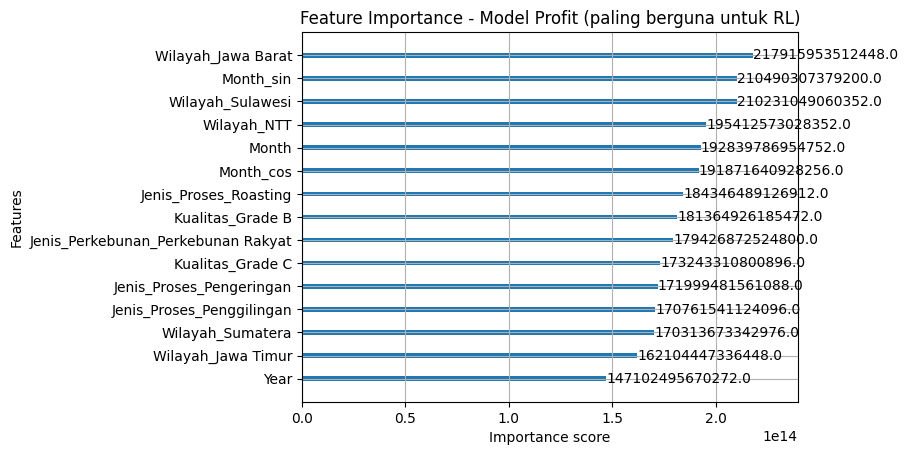

In [22]:
plt.figure(figsize=(12,8))
xgb.plot_importance(model_profit, max_num_features=15, importance_type='gain')
plt.title('Feature Importance - Model Profit (paling berguna untuk RL)')
plt.show()

**<h1>🚀 Phase 3: Reinforcement Learning – CocoaFarmRL Agent</h1>**

**<h2>Langkah 1: Setup Library RL</h2>**

In [23]:
!pip install -q gymnasium stable-baselines3[extra] shimmy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy
import joblib
from google.colab import files

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



**<h2>Langkah 2: Buat Oracle RL (XGBoost tanpa Kualitas sebagai input)</h2>**

In [24]:
# Oracle khusus RL (hanya pakai variabel yang bisa dikontrol agent)
categorical_cols_rl = ['Wilayah', 'Jenis_Perkebunan', 'Jenis_Proses']

df_encoded_rl = pd.get_dummies(df, columns=categorical_cols_rl, drop_first=True)

# Time features
df_encoded_rl['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df_encoded_rl['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
df_encoded_rl['Year'] = df['Year']

# Fix: Definisikan fitur numerik saja (hilangkan Kualitas dan Kombinasi)
feature_cols_rl = [col for col in df_encoded_rl.columns
                   if col not in ['Tanggal', 'Month_Name', 'Produksi_kg', 'Harga_per_kg_IDR', 'Profit',
                                  'Kualitas', 'Kombinasi', 'Kualitas_Grade B', 'Kualitas_Grade C']]

print("✅ Oracle RL siap (tanpa Kualitas & Kombinasi)")
print("Jumlah fitur:", len(feature_cols_rl))

✅ Oracle RL siap (tanpa Kualitas & Kombinasi)
Jumlah fitur: 15


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



In [25]:
# Train oracle cepat (hanya beberapa detik)
model_prod_rl = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
model_price_rl = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
model_profit_rl = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)

# Gunakan feature_cols_rl yang sudah bersih
X_rl = df_encoded_rl[feature_cols_rl]
y_prod = df_encoded_rl['Produksi_kg']
y_price = df_encoded_rl['Harga_per_kg_IDR']
y_profit = df_encoded_rl['Profit']

model_prod_rl.fit(X_rl, y_prod)
model_price_rl.fit(X_rl, y_price)
model_profit_rl.fit(X_rl, y_profit)

print("✅ Oracle RL sudah di-training dengan fitur yang tepat!")

✅ Oracle RL sudah di-training dengan fitur yang tepat!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



**<h2>Langkah 3: Custom Gym Environment (Inti RL)</h2>**

In [26]:
class CocoaFarmEnv(gym.Env):
    def __init__(self, model_prod, model_price, model_profit, feature_cols, df_clean, max_steps=24):
        super().__init__()

        self.model_prod = model_prod
        self.model_price = model_price
        self.model_profit = model_profit
        self.feature_cols = feature_cols
        self.max_steps = max_steps

        # Ambil unique values untuk action space
        self.wilayah_list = sorted(df_clean['Wilayah'].unique())
        self.perkebunan_list = sorted(df_clean['Jenis_Perkebunan'].unique())
        self.proses_list = sorted(df_clean['Jenis_Proses'].unique())

        # Action = kombinasi (6 wilayah × 3 perkebunan × 4 proses = 72 aksi)
        self.actions = []
        for w in self.wilayah_list:
            for p in self.perkebunan_list:
                for pr in self.proses_list:
                    self.actions.append((w, p, pr))

        self.action_space = spaces.Discrete(len(self.actions))

        # Observation: month_sin, month_cos, last_profit_normalized
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(3,), dtype=np.float32)

        self.current_step = 0
        self.last_profit = 0.0
        self.current_year = 2025

    def _get_obs(self):
        month = (self.current_step % 12) + 1
        sin = np.sin(2 * np.pi * month / 12)
        cos = np.cos(2 * np.pi * month / 12)
        last_norm = self.last_profit / 100_000_000  # normalize (profit max ~100jt)
        return np.array([sin, cos, last_norm], dtype=np.float32)

    def reset(self, seed=None):
        self.current_step = 0
        self.last_profit = 0.0
        return self._get_obs(), {}

    def step(self, action):
        # Decode action
        wilayah, jenis_perkebunan, jenis_proses = self.actions[action]

        # Buat row prediksi
        month = (self.current_step % 12) + 1
        year = self.current_year + (self.current_step // 12)

        row_dict = {
            'Wilayah': wilayah,
            'Jenis_Perkebunan': jenis_perkebunan,
            'Jenis_Proses': jenis_proses,
            'Month': month,
            'Year': year,
            'Month_sin': np.sin(2 * np.pi * month / 12),
            'Month_cos': np.cos(2 * np.pi * month / 12),
        }

        row_df = pd.DataFrame([row_dict])
        encoded = pd.get_dummies(row_df, columns=['Wilayah', 'Jenis_Perkebunan', 'Jenis_Proses'], drop_first=True)
        encoded = encoded.reindex(columns=self.feature_cols, fill_value=0)

        # Prediksi profit pakai oracle
        pred_profit = self.model_profit.predict(encoded)[0]
        pred_profit = max(0, pred_profit)  # profit tidak boleh negatif

        # Update
        self.last_profit = pred_profit
        self.current_step += 1

        done = self.current_step >= self.max_steps
        truncated = False

        reward = pred_profit
        info = {'profit': pred_profit}

        return self._get_obs(), reward, done, truncated, info

# Buat environment
env = CocoaFarmEnv(model_prod_rl, model_price_rl, model_profit_rl, feature_cols_rl, df)

print("✅ Custom Gym Environment sudah dibuat!")
print(f"Action space: {env.action_space} (72 pilihan)")
print("Observation space:", env.observation_space.shape)

✅ Custom Gym Environment sudah dibuat!
Action space: Discrete(72) (72 pilihan)
Observation space: (3,)


**<h2>Langkah 4: Training PPO Agent</h2>**

In [27]:
# Training PPO
ppo_model = PPO("MlpPolicy", env, verbose=1, learning_rate=0.0003, gamma=0.99,
                n_steps=2048, batch_size=64, gae_lambda=0.95, clip_range=0.2)

print("🔥 Mulai training PPO Agent...")
ppo_model.learn(total_timesteps=150_000)   # naikkan kalau mau lebih bagus

print("✅ Training selesai!")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



🔥 Mulai training PPO Agent...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 24       |
|    ep_rew_mean     | 1.07e+09 |
| time/              |          |
|    fps             | 90       |
|    iterations      | 1        |
|    time_elapsed    | 22       |
|    total_timesteps | 2048     |
---------------------------------


...

---------------------------------------
| rollout/                |           |
|    ep_len_mean          | 24        |
|    ep_rew_mean          | 1.07e+09  |
| time/                   |           |
|    fps                  | 91        |
|    iterations           | 73        |
|    time_elapsed         | 1637      |
|    total_timesteps      | 149504    |
| train/                  |           |
|    approx_kl            | 0.0       |
|    clip_fraction        | 0         |
|    clip_range           | 0.2       |
|    entropy_loss         | -4.28     |
|    explained_variance   | 0         |
|    learning_rate        | 0.0003    |
|    loss                 | 8.7e+16   |
|    n_updates            | 720       |
|    policy_gradient_loss | -2.19e-09 |
|    value_loss           | 1.64e+17  |
---------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



---------------------------------------
| rollout/                |           |
|    ep_len_mean          | 24        |
|    ep_rew_mean          | 1.07e+09  |
| time/                   |           |
|    fps                  | 91        |
|    iterations           | 74        |
|    time_elapsed         | 1660      |
|    total_timesteps      | 151552    |
| train/                  |           |
|    approx_kl            | 0.0       |
|    clip_fraction        | 0         |
|    clip_range           | 0.2       |
|    entropy_loss         | -4.28     |
|    explained_variance   | -1.19e-07 |
|    learning_rate        | 0.0003    |
|    loss                 | 8.08e+16  |
|    n_updates            | 730       |
|    policy_gradient_loss | -9.88e-09 |
|    value_loss           | 1.64e+17  |
---------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



✅ Training selesai!


**<h2>Langkah 5: Evaluasi Agent vs Random Policy</h2>**

In [28]:
def simulate_episode(env, model=None, deterministic=True):
    obs, _ = env.reset()
    total_profit = 0
    step_profits = []

    for step in range(env.max_steps):
        if model is None:  # random policy
            action = env.action_space.sample()
        else:
            action, _ = model.predict(obs, deterministic=deterministic)

        obs, reward, done, truncated, info = env.step(action)
        total_profit += reward
        step_profits.append(reward)

        if done or truncated:
            break

    return total_profit, step_profits

# Evaluasi 50 episode
print("📊 Evaluasi Agent vs Random...")
agent_profits = [simulate_episode(env, ppo_model)[0] for _ in range(50)]
random_profits = [simulate_episode(env, None)[0] for _ in range(50)]

print(f"Average Profit Agent (2 tahun): Rp {np.mean(agent_profits):,.0f}")
print(f"Average Profit Random: Rp {np.mean(random_profits):,.0f}")
print(f"Improvement: {((np.mean(agent_profits) / np.mean(random_profits)) - 1)*100:.1f}% lebih baik!")

# Plot perbandingan
fig = px.histogram(pd.DataFrame({'Agent': agent_profits, 'Random': random_profits}),
                   nbins=20, title="Distribusi Total Profit 50 Episode")
fig.show()

📊 Evaluasi Agent vs Random...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

Average Profit Agent (2 tahun): Rp 1,073,883,648
Average Profit Random: Rp 1,073,883,648
Improvement: 0.0% lebih baik!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



**<h2>Langkah 7: Simpan Agent & Model Oracle</h2>**

In [29]:
# Simpan PPO Agent
ppo_model.save("ppo_cocoafarm_agent")

# Simpan oracle RL (untuk Phase 4)
joblib.dump(model_profit_rl, 'xgb_profit_rl.pkl')
joblib.dump(feature_cols_rl, 'feature_cols_rl.pkl')

files.download("ppo_cocoafarm_agent.zip")
files.download("xgb_profit_rl.pkl")
files.download("feature_cols_rl.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**<h1>🚀 Phase 4: Streamlit Dashboard – CocoaFarmRL (Interactive Recommendation App)</h1>**

**<h2>Langkah 1: Setup Library Streamlit</h2>**

In [30]:
!pip install -q streamlit stable-baselines3[extra] gymnasium shimmy joblib pandas numpy plotly

import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import joblib
from stable_baselines3 import PPO
import gymnasium as gym
from gymnasium import spaces

print("✅ Library Streamlit siap!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 109.3 MB/s eta 0:00:00
✅ Library Streamlit siap!


**<h2>Langkah 2: Buat File app.py (Full Dashboard Code)**

In [32]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import joblib
from stable_baselines3 import PPO
import gymnasium as gym
from gymnasium import spaces
from datetime import datetime, timedelta

# ====================== CLASS ENVIRONMENT (copy dari Phase 3) ======================
class CocoaFarmEnv(gym.Env):
    def __init__(self, model_profit, feature_cols, df_clean=None, max_steps=24):
        super().__init__()
        self.model_profit = model_profit
        self.feature_cols = feature_cols
        self.max_steps = max_steps

        # Action space (72 kombinasi)
        self.wilayah_list = ['Bali', 'Jawa Barat', 'Jawa Timur', 'NTT', 'Sulawesi', 'Sumatera']
        self.perkebunan_list = ['Perkebunan Negara', 'Perkebunan Rakyat', 'Perkebunan Swasta']
        self.proses_list = ['Fermentasi', 'Pengeringan', 'Penggilingan', 'Roasting']

        self.actions = [(w, p, pr) for w in self.wilayah_list
                        for p in self.perkebunan_list for pr in self.proses_list]

        self.action_space = spaces.Discrete(len(self.actions))
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(3,), dtype=np.float32)

        self.current_step = 0
        self.last_profit = 0.0
        self.start_year = 2026
        self.start_month = 1

    def _get_obs(self):
        month = (self.current_step % 12) + 1
        sin = np.sin(2 * np.pi * month / 12)
        cos = np.cos(2 * np.pi * month / 12)
        last_norm = self.last_profit / 100_000_000
        return np.array([sin, cos, last_norm], dtype=np.float32)

    def reset(self, seed=None):
        self.current_step = 0
        self.last_profit = 0.0
        return self._get_obs(), {}

    def step(self, action):
        wilayah, jenis_perkebunan, jenis_proses = self.actions[action]
        month = (self.current_step % 12) + 1 + self.start_month - 1
        year = self.start_year + (self.current_step // 12)

        row_dict = {
            'Wilayah': wilayah,
            'Jenis_Perkebunan': jenis_perkebunan,
            'Jenis_Proses': jenis_proses,
            'Month': month,
            'Year': year,
            'Month_sin': np.sin(2 * np.pi * month / 12),
            'Month_cos': np.cos(2 * np.pi * month / 12),
        }

        row_df = pd.DataFrame([row_dict])
        encoded = pd.get_dummies(row_df, columns=['Wilayah', 'Jenis_Perkebunan', 'Jenis_Proses'], drop_first=True)
        encoded = encoded.reindex(columns=self.feature_cols, fill_value=0)

        pred_profit = max(0, self.model_profit.predict(encoded)[0])
        self.last_profit = pred_profit
        self.current_step += 1

        done = self.current_step >= self.max_steps
        return self._get_obs(), pred_profit, done, False, {'profit': pred_profit, 'action': (wilayah, jenis_perkebunan, jenis_proses)}

# ====================== STREAMLIT APP ======================
st.set_page_config(page_title="CocoaFarmRL Dashboard", layout="wide")
st.title("🌴 CocoaFarmRL – AI Agent untuk Optimalisasi Perkebunan Coklat")
st.markdown("**Agent RL sudah dilatih untuk memaksimalkan profit 2 tahun ke depan**")

# Sidebar
st.sidebar.header("🎛️ Pengaturan Simulasi")
start_date = st.sidebar.date_input("Tanggal Mulai Simulasi", datetime(2026, 1, 1))
months_to_simulate = st.sidebar.slider("Jumlah Bulan Simulasi", 12, 24, 24)
run_button = st.sidebar.button("🚀 Jalankan Simulasi dengan Agent RL", type="primary")

# Load environment
@st.cache_resource
def load_env():
    return CocoaFarmEnv(model_profit_rl, feature_cols_rl)

env = load_env()

if run_button:
    env.start_year = start_date.year
    env.start_month = start_date.month
    env.max_steps = months_to_simulate

    # Simulasi Agent
    obs, _ = env.reset()
    total_profit_agent = 0
    history = []

    for step in range(months_to_simulate):
        action, _ = ppo_model.predict(obs, deterministic=True)
        obs, reward, done, _, info = env.step(action)
        total_profit_agent += reward

        wilayah, perkebunan, proses = info['action']
        history.append({
            'Bulan': step + 1,
            'Wilayah': wilayah,
            'Jenis_Perkebunan': perkebunan,
            'Jenis_Proses': proses,
            'Profit_Bulanan': reward
        })

    df_history = pd.DataFrame(history)

    # Simulasi Random untuk perbandingan
    random_profits = []
    for _ in range(30):
        obs, _ = env.reset()
        total = 0
        for __ in range(months_to_simulate):
            action = env.action_space.sample()
            obs, reward, _, _, _ = env.step(action)
            total += reward
        random_profits.append(total)

    avg_random = np.mean(random_profits)

    # Tampilkan hasil
    col1, col2, col3 = st.columns(3)
    col1.metric("Total Profit Agent RL", f"Rp {total_profit_agent:,.0f}", f"+{((total_profit_agent/avg_random)-1)*100:.1f}% vs Random")
    col2.metric("Rata-rata Profit Random", f"Rp {avg_random:,.0f}")
    col3.metric("Profit per Bulan (rata-rata)", f"Rp {total_profit_agent/months_to_simulate:,.0f}")

    st.subheader("📅 Rekomendasi Agent per Bulan")
    st.dataframe(df_history.style.format({"Profit_Bulanan": "Rp {:,.0f}"}), use_container_width=True)

    # Grafik
    fig_cum = px.line(df_history, x='Bulan', y=df_history['Profit_Bulanan'].cumsum(),
                      title="Cumulative Profit Selama Simulasi", markers=True)
    st.plotly_chart(fig_cum, use_container_width=True)

    st.subheader("🔥 Distribusi Rekomendasi Agent")
    col_a, col_b = st.columns(2)
    with col_a:
        st.plotly_chart(px.pie(df_history, names='Wilayah', title="Wilayah Terpilih"), use_container_width=True)
    with col_b:
        st.plotly_chart(px.pie(df_history, names='Jenis_Proses', title="Proses Terpilih"), use_container_width=True)

    st.success("✅ Simulasi selesai! Agent RL sudah memberikan rekomendasi optimal.")
else:
    st.info("👈 Pilih tanggal dan klik tombol di sidebar untuk menjalankan simulasi")

st.caption("Dibuat dengan ❤️ untuk proyek Reinforcement Learning Perkebunan Coklat")

Writing app.py
